<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/Section_4_Creating_a_Time_Series_Object_in_Python_Completed_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing the Packages

In [21]:
import pandas as pd
import numpy as np

### Importing the data

In [22]:
raw_csv_data = pd.read_csv("/content/sample_data/Index2018.csv") #read directly from Pandas library
df_comp = raw_csv_data.copy() #df_comp --> complete DataFrame

### Lenght of the Time Period

In [23]:
df_comp.describe() #date is not nuber column, the Python doesn't iclude to statistic

,spx,dax,ftse,nikkei
count,6269.000000,6269.000000,6269.000000,6269.000000
mean,1288.127542,6080.063363,5422.713545,14597.055700
std,487.586473,2754.361032,1145.572428,4043.122953
min,438.920000,1911.700000,2876.600000,7054.980000
25%,990.671905,4069.350000,4486.100000,10709.290000
50%,1233.420000,5773.340000,5662.430000,15028.170000
75%,1459.987747,7443.070000,6304.250000,17860.470000
max,2872.867839,13559.600000,7778.637689,24124.150000


In [24]:
df_comp.head()

,date,spx,dax,ftse,nikkei
0,07/01/1994,469.90,2224.95,3445.98,18124.01
1,10/01/1994,475.27,2225.00,3440.58,18443.44
2,11/01/1994,474.13,2228.10,3413.77,18485.25
3,12/01/1994,474.17,2182.06,3372.02,18793.88
4,13/01/1994,472.47,2142.37,3360.01,18577.26


In [25]:
df_comp.date.describe()

,date
count,6269
unique,6269
top,29/01/2018
freq,1


### From Text to Date

In [26]:
df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True) #transform to date format, write to df_comp as column date

In [27]:
df_comp.head() #look at integer column on the left, then go below 3 cells

,date,spx,dax,ftse,nikkei
0,1994-01-07,469.90,2224.95,3445.98,18124.01
1,1994-01-10,475.27,2225.00,3440.58,18443.44
2,1994-01-11,474.13,2228.10,3413.77,18485.25
3,1994-01-12,474.17,2182.06,3372.02,18793.88
4,1994-01-13,472.47,2142.37,3360.01,18577.26


In [28]:
df_comp.date.describe()

,date
count,6269
mean,2006-01-14 19:36:59.492742144
min,1994-01-07 00:00:00
25%,2000-01-11 00:00:00
50%,2006-01-12 00:00:00
75%,2012-01-19 00:00:00
max,2018-01-29 00:00:00


### Setting the Index

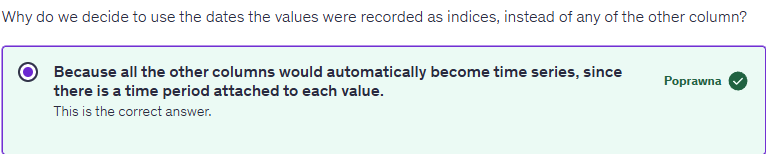

In [29]:
df_comp.set_index("date")

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.900000,2224.95,3445.980000,18124.01
1994-01-10,475.270000,2225.00,3440.580000,18443.44
1994-01-11,474.130000,2228.10,3413.770000,18485.25
1994-01-12,474.170000,2182.06,3372.020000,18793.88
1994-01-13,472.470000,2142.37,3360.010000,18577.26
...,...,...,...,...
2018-01-23,2839.130362,13559.60,7731.827774,24124.15
2018-01-24,2837.544008,13414.74,7643.428966,23940.78
2018-01-25,2839.253031,13298.36,7615.839954,23669.49


In [30]:
df_comp.set_index("date", inplace=True)  # set the "date" column as the DataFrame index (inplace=True modifies df_comp directly)
# after command there is no index (int) on the left. date is used as index

In [31]:
df_comp.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25
1994-01-12,474.17,2182.06,3372.02,18793.88
1994-01-13,472.47,2142.37,3360.01,18577.26


In [32]:
df_comp.date.describe() #Expect to get an error message because we no longer have a "date" column since it is the index

AttributeError: 'DataFrame' object has no attribute 'date'

### Setting the Desired Frequency

W asfreq() podajesz częstotliwość (frequency) jako offset alias. 'D'/'d' to „dzień”. Inne typowe opcje:

Godziny / minuty / sekundy

'H' – godzina

'T' lub 'min' – minuta

'S' – sekunda

'ms', 'us', 'ns' – milisekunda / mikrosekunda / nanosekunda

Tygodnie

'W' – tydzień (domyślnie tydzień kończy się w niedzielę)

'W-MON', 'W-TUE', … – tydzień kończący się w konkretny dzień

Miesiące / kwartały / lata

'M' – koniec miesiąca

'MS' – początek miesiąca

'Q' – koniec kwartału

'QS' – początek kwartału

'A' / 'Y' – koniec roku

'AS' / 'YS' – początek roku

Dni robocze i „biznesowe”

'B' – dzień roboczy (Mon–Fri)

'BM' / 'BMS' – koniec / początek miesiąca roboczego

'BQ' / 'BQS' – koniec / początek kwartału roboczego

'BA' / 'BAS' – koniec / początek roku roboczego

Co N jednostek

'2H', '15T', '30S', '3D', '2W', '6M', '5B' itd.

Drobna pułapka: w pandas częściej spotkasz wielkie litery ('D', 'H', 'M'), ale 'd' zwykle działa jako synonim dnia.

asfreq() nie agreguje danych. Ona tylko narzuca nową siatkę czasu na index i:

jeśli w nowej siatce nie ma obserwacji → wstawia NaN

jeśli miałeś dane „gęstsze” niż nowa siatka → bierze tylko te punkty, które dokładnie trafiają w znaczniki czasu (reszta przepada)

resample() robi próbkowanie z agregacją/interpolacją:

grupuje dane w koszyki czasowe i pozwala policzyć np. mean/sum/last/ohlc

potrafi też wypełniać braki metodami typu ffill, interpolate, itd.

In [37]:
df_comp=df_comp.asfreq('D') #equalizing frequency of data timeseries
# d - daily
# w - weekly
# h - hourly
# m - monthly

In [38]:
df_comp

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.900000,2224.95,3445.980000,18124.01
1994-01-08,NaN,NaN,NaN,NaN
1994-01-09,NaN,NaN,NaN,NaN
1994-01-10,475.270000,2225.00,3440.580000,18443.44
1994-01-11,474.130000,2228.10,3413.770000,18485.25
...,...,...,...,...
2018-01-25,2839.253031,13298.36,7615.839954,23669.49
2018-01-26,2872.867839,13340.17,7665.541292,23631.88
2018-01-27,NaN,NaN,NaN,NaN


In [39]:
df_comp=df_comp.asfreq('b')

In [40]:
df_comp.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25
1994-01-12,474.17,2182.06,3372.02,18793.88
1994-01-13,472.47,2142.37,3360.01,18577.26


### Handling Missing Values

In [41]:
df_comp.isna()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,False,False,False,False
1994-01-10,False,False,False,False
1994-01-11,False,False,False,False
1994-01-12,False,False,False,False
1994-01-13,False,False,False,False
...,...,...,...,...
2018-01-23,False,False,False,False
2018-01-24,False,False,False,False
2018-01-25,False,False,False,False


In [42]:
df_comp.isna().sum()

,0
spx,8
dax,8
ftse,8
nikkei,8


In [43]:
df_comp

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.900000,2224.95,3445.980000,18124.01
1994-01-10,475.270000,2225.00,3440.580000,18443.44
1994-01-11,474.130000,2228.10,3413.770000,18485.25
1994-01-12,474.170000,2182.06,3372.020000,18793.88
1994-01-13,472.470000,2142.37,3360.010000,18577.26
...,...,...,...,...
2018-01-23,2839.130362,13559.60,7731.827774,24124.15
2018-01-24,2837.544008,13414.74,7643.428966,23940.78
2018-01-25,2839.253031,13298.36,7615.839954,23669.49


In [44]:
df_comp.spx = df_comp.spx.fillna(method="ffill")  # fill missing values in column 'spx' by forward-filling (use the last known value)


/tmp/ipython-input-787069143.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_comp.spx = df_comp.spx.fillna(method="ffill")  # fill missing values in column 'spx' by forward-filling (use the last known value)


value=... — wypełnia NaN stałą wartością (np. 0, średnia, mediana, tekst).

value={kolumna: wartość, ...} — wypełnia NaN różnymi wartościami per kolumna.

method="ffill" — forward fill: bierze poprzednią znaną wartość.

method="bfill" — backward fill: bierze następną znaną wartość.

limit=... — ogranicza ffill/bfill do maks. tylu kolejnych NaN-ów (żeby nie ciągnąć jednej wartości w nieskończoność).

axis=0 — wypełnia wzdłuż wierszy / czasu (domyślnie).

axis=1 — wypełnia wzdłuż kolumn (poziomo).

inplace=True — modyfikuje obiekt na miejscu zamiast zwracać kopię.

downcast="infer" — próbuje zoptymalizować typ (np. float → int, gdy się da); używane rzadko.

limit_area="inside" — wypełnia tylko dziury „w środku” (nie na początku/końcu serii).

limit_area="outside" — wypełnia tylko NaN-y na brzegach (na początku/końcu), a nie te w środku.

In [45]:
df_comp.isna().sum()

,0
spx,0
dax,8
ftse,8
nikkei,8


In [46]:
df_comp.ftse=df_comp.ftse.fillna(method='bfill')

/tmp/ipython-input-368338788.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_comp.ftse=df_comp.ftse.fillna(method='bfill')


In [48]:
df_comp.dax=df_comp.dax.fillna(value = df_comp.dax.mean())

In [49]:
df_comp.isna().sum()

,0
spx,0
dax,0
ftse,0
nikkei,8


### Simplifying the Dataset

In [51]:
df_comp['market_value']=df_comp.spx #add column 'market value' and copy spx there

In [52]:
df_comp.describe()

,spx,dax,ftse,nikkei,market_value
count,6277.000000,6277.000000,6277.000000,6269.000000,6277.000000
mean,1288.642547,6080.063363,5423.690398,14597.055700,1288.642547
std,487.868210,2752.604984,1145.568370,4043.122953,487.868210
min,438.920000,1911.700000,2876.600000,7054.980000,438.920000
25%,992.715221,4070.460000,4487.880000,10709.290000,992.715221
50%,1233.761241,5774.380000,5663.300000,15028.170000,1233.761241
75%,1460.250000,7442.660000,6304.630175,17860.470000,1460.250000
max,2872.867839,13559.600000,7778.637689,24124.150000,2872.867839


In [53]:
del df_comp['spx'] #delete column

In [54]:
df_comp.describe()

,dax,ftse,nikkei,market_value
count,6277.000000,6277.000000,6269.000000,6277.000000
mean,6080.063363,5423.690398,14597.055700,1288.642547
std,2752.604984,1145.568370,4043.122953,487.868210
min,1911.700000,2876.600000,7054.980000,438.920000
25%,4070.460000,4487.880000,10709.290000,992.715221
50%,5774.380000,5663.300000,15028.170000,1233.761241
75%,7442.660000,6304.630175,17860.470000,1460.250000
max,13559.600000,7778.637689,24124.150000,2872.867839


In [55]:
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']

In [56]:
df_comp.describe()

,market_value
count,6277.000000
mean,1288.642547
std,487.868210
min,438.920000
25%,992.715221
50%,1233.761241
75%,1460.250000
max,2872.867839


### Splitting the Data

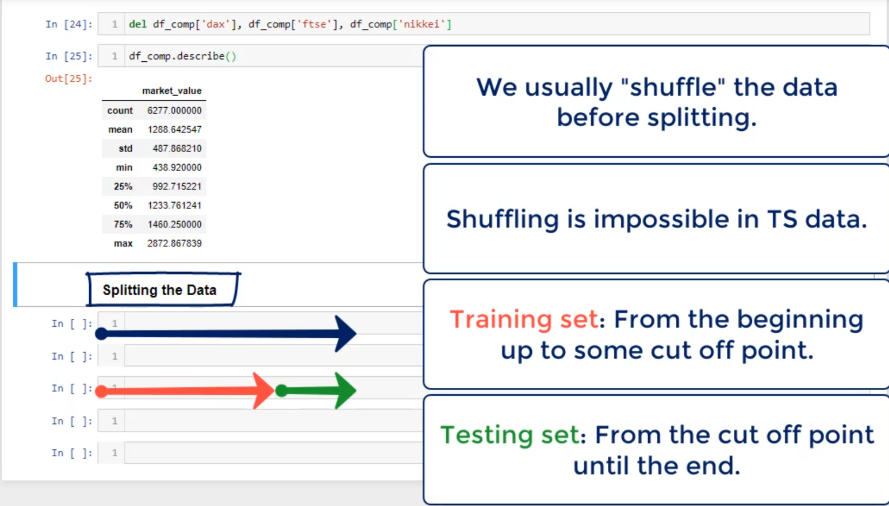

In [58]:
size = int(len(df_comp)*0.8) #count the lenght of training data

In [60]:
size

5021

Time series uses ILOC method for split the data

In [63]:
df = df_comp.iloc[:size] #training data
df.count()

,0
market_value,5021


In [64]:
df_test = df_comp.iloc[size:] #testing data
df_test.count()

,0
market_value,1256


In [65]:
df.tail()

,market_value
date,
2013-04-01,1562.173837
2013-04-02,1570.252238
2013-04-03,1553.686978
2013-04-04,1559.979316
2013-04-05,1553.278930


In [66]:
df_test.head()

,market_value
date,
2013-04-08,1563.071269
2013-04-09,1568.607909
2013-04-10,1587.731827
2013-04-11,1593.369863
2013-04-12,1588.854623
